# ❤️ Heart Disease Prediction - Group 6

**Môn học:** Machine Learning cơ bản  
**Dataset:** 918 bệnh nhân, 11 chỉ số y tế  
**Mục tiêu:** Phân loại nhị phân (Có/Không bệnh tim)

---
## 📋 Pipeline
1. **EDA** - Khám phá & làm sạch dữ liệu
2. **Preprocessing** - Chuẩn hóa & mã hóa features
3. **Visualization** - Trực quan hóa dữ liệu
4. **Custom Decision Tree** - Tự code + Tuning
5. **Custom Naive Bayes** - Tự code + Đánh giá
6. **So sánh với Sklearn** - LR, KNN, SVM, Random Forest

In [1]:
# === CELL 1: IMPORT THƯ VIỆN & CÀI ĐẶT ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cài đặt hiển thị
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_palette('Set2')

# Tải dữ liệu từ GitHub (để chạy trên Colab không cần upload)
url = 'https://raw.githubusercontent.com/Minh08012005/Heart-Disease-Prediction-ML-Group-6/main/data/heart.csv'
df = pd.read_csv(url)

print(f'✅ Đã tải {len(df)} mẫu, {len(df.columns)} cột')
print(f'✅ Dataset: heart.csv (từ GitHub repo)')

✅ Đã tải 918 mẫu, 12 cột
✅ Dataset: heart.csv (từ GitHub repo)


---
## 📌 BƯỚC 1: EDA - EXPLORATORY DATA ANALYSIS

In [2]:
# === CELL 2: THÔNG TIN CƠ BẢN ===
print('=== 5 DÒNG ĐẦU TIÊN ===')
print(df.head())
print()
print('=== THÔNG TIN CÁC CỘT ===')
print(df.info())
print()
print('=== MÔ TẢ THỐNG KÊ ===')
print(df.describe())

=== 5 DÒNG ĐẦU TIÊN ===
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

=== THÔNG TIN CÁC CỘT ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  -

In [3]:
# === CELL 3: GIẢI THÍCH FEATURES & PHÂN BỐ TARGET ===
print('=== GIẢI THÍCH FEATURES ===')
feature_explanations = {
    'Age': 'Tuổi của bệnh nhân (năm)',
    'Sex': 'Giới tính (M: Nam, F: Nữ)',
    'ChestPainType': 'Loại đau ngực (ATA, NAP, ASY, TA)',
    'RestingBP': 'Huyết áp lúc nghỉ (mmHg)',
    'Cholesterol': 'Cholesterol huyết thanh (mg/dL)',
    'FastingBS': 'Đường huyết lúc đói (0: <120, 1: >120 mg/dL)',
    'RestingECG': 'Kết quả điện tâm đồ lúc nghỉ (Normal, ST, LVH)',
    'MaxHR': 'Nhịp tim tối đa đạt được',
    'ExerciseAngina': 'Đau ngực do gắng sức (Y: Có, N: Không)',
    'Oldpeak': 'ST depression (chỉ số thiếu máu cơ tim)',
    'ST_Slope': 'Độ dốc đoạn ST (Up, Flat, Down)',
    'HeartDisease': 'MỤC TIÊU: 0=Không bệnh, 1=Có bệnh tim'
}
for col, desc in feature_explanations.items():
    print(f'  {col:20s}: {desc}')
print()
print('=== PHÂN BỐ TARGET (HeartDisease) ===')
print(df['HeartDisease'].value_counts())
print(f'  Tỷ lệ: {df["HeartDisease"].mean()*100:.1f}% có bệnh tim')

=== GIẢI THÍCH FEATURES ===
  Age                 : Tuổi của bệnh nhân (năm)
  Sex                 : Giới tính (M: Nam, F: Nữ)
  ChestPainType       : Loại đau ngực (ATA, NAP, ASY, TA)
  RestingBP           : Huyết áp lúc nghỉ (mmHg)
  Cholesterol         : Cholesterol huyết thanh (mg/dL)
  FastingBS           : Đường huyết lúc đói (0: <120, 1: >120 mg/dL)
  RestingECG          : Kết quả điện tâm đồ lúc nghỉ (Normal, ST, LVH)
  MaxHR               : Nhịp tim tối đa đạt được
  ExerciseAngina      : Đau ngực do gắng sức (Y: Có, N: Không)
  Oldpeak             : ST depression (chỉ số thiếu máu cơ tim)
  ST_Slope            : Độ dốc đoạn ST (Up, Flat, Down)
  HeartDisease        : MỤC TIÊU: 0=Không bệnh, 1=Có bệnh tim

=== PHÂN BỐ TARGET (HeartDisease) ===
HeartDisease
1    508
0    410
Name: count, dtype: int64
  Tỷ lệ: 55.3% có bệnh tim


In [4]:
# === CELL 4: PHÁT HIỆN & XỬ LÝ GIÁ TRỊ 0 VÔ LÝ ===
print('=== KIỂM TRA GIÁ TRỊ 0 VÔ LÝ ===')
for col in ['RestingBP', 'Cholesterol']:
    zero_count = (df[col] == 0).sum()
    if zero_count > 0:
        print(f'  ⚠️ {col}: CÓ {zero_count} giá trị bằng 0 ({zero_count/len(df)*100:.1f}%)')

# Xử lý Cholesterol = 0 bằng median theo từng nhóm
median_0 = df[df['HeartDisease'] == 0]['Cholesterol'].median()
median_1 = df[df['HeartDisease'] == 1]['Cholesterol'].median()
df.loc[(df['Cholesterol'] == 0) & (df['HeartDisease'] == 0), 'Cholesterol'] = median_0
df.loc[(df['Cholesterol'] == 0) & (df['HeartDisease'] == 1), 'Cholesterol'] = median_1

# Xử lý RestingBP = 0 bằng median
median_bp = df['RestingBP'].median()
df.loc[df['RestingBP'] == 0, 'RestingBP'] = median_bp

print(f'  ✅ Đã xử lý Cholesterol = 0 (median không bệnh={median_0}, có bệnh={median_1})')
print(f'  ✅ Đã xử lý RestingBP = 0 (median={median_bp})')
print(f'  ✅ Không còn giá trị 0 vô lý!')

=== KIỂM TRA GIÁ TRỊ 0 VÔ LÝ ===
  ⚠️ RestingBP: CÓ 1 giá trị bằng 0 (0.1%)
  ⚠️ Cholesterol: CÓ 172 giá trị bằng 0 (18.7%)
  ✅ Đã xử lý Cholesterol = 0 (median không bệnh=227.0, có bệnh=217.0)
  ✅ Đã xử lý RestingBP = 0 (median=130.0)
  ✅ Không còn giá trị 0 vô lý!


In [5]:
# === CELL 5: THỐNG KÊ TUỔI, GIỚI TÍNH, CHESTPAINTYPE ===
print('=== TUỔI TRUNG BÌNH THEO NHÓM BỆNH ===')
print(df.groupby('HeartDisease')['Age'].describe())
print()

print('=== TỶ LỆ BỆNH THEO GIỚI TÍNH ===')
print(pd.crosstab(df['Sex'], df['HeartDisease'], margins=True))
print()

print('=== TỶ LỆ BỆNH THEO CHESTPAINTYPE ===')
ct = pd.crosstab(df['ChestPainType'], df['HeartDisease'])
ct['Tỷ lệ bệnh (%)'] = (ct[1] / (ct[0] + ct[1]) * 100).round(2)
print(ct)

=== TUỔI TRUNG BÌNH THEO NHÓM BỆNH ===
              count       mean       std   min   25%   50%   75%   max
HeartDisease                                                          
0             410.0  50.551220  9.444915  28.0  43.0  51.0  57.0  76.0
1             508.0  55.899606  8.727056  31.0  51.0  57.0  62.0  77.0

=== TỶ LỆ BỆNH THEO GIỚI TÍNH ===
HeartDisease    0    1  All
Sex                        
F             143   50  193
M             267  458  725
All           410  508  918

=== TỶ LỆ BỆNH THEO CHESTPAINTYPE ===
HeartDisease     0    1  Tỷ lệ bệnh (%)
ChestPainType                          
ASY            104  392           79.03
ATA            149   24           13.87
NAP            131   72           35.47
TA              26   20           43.48


In [6]:
# === CELL 6: KIỂM TRA TÍNH TUYẾN TÍNH ===
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

X_test_linear = df.drop('HeartDisease', axis=1).select_dtypes(include=[np.number])
y_test_linear = df['HeartDisease']

lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(max_depth=5, random_state=42)

lr_scores = cross_val_score(lr, X_test_linear, y_test_linear, cv=5)
dt_scores = cross_val_score(dt, X_test_linear, y_test_linear, cv=5)

print('=== KIỂM TRA TUYẾN TÍNH VS PHI TUYẾN ===')
print(f'  Logistic Regression (tuyến tính): {lr_scores.mean():.3f}')
print(f'  Decision Tree (phi tuyến):       {dt_scores.mean():.3f}')
if lr_scores.mean() > dt_scores.mean():
    print('  ✅ Dữ liệu có XU HƯỚNG TUYẾN TÍNH!')
else:
    print('  ⚠️ Dữ liệu có XU HƯỚNG PHI TUYẾN!')

=== KIỂM TRA TUYẾN TÍNH VS PHI TUYẾN ===
  Logistic Regression (tuyến tính): 0.747
  Decision Tree (phi tuyến):       0.714
  ✅ Dữ liệu có XU HƯỚNG TUYẾN TÍNH!


---
## 📌 BƯỚC 2: PREPROCESSING (StandardScaler + OneHotEncoder)

In [7]:
# === CELL 7: PREPROCESSING ===
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Định nghĩa các cột số và phân loại
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
categorical_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# Tạo preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

# Tách X, y
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease'].values

# Fit-transform
X_processed = preprocessor.fit_transform(X)

# Lấy tên features
feature_names = []
for name, transformer, columns in preprocessor.transformers_:
    if name == 'num':
        feature_names.extend(columns)
    elif name == 'cat':
        cat_names = transformer.get_feature_names_out(columns)
        feature_names.extend(cat_names)

print(f'✅ Preprocessing xong: {X_processed.shape[0]} mẫu, {X_processed.shape[1]} features')
print(f'\nDanh sách {len(feature_names)} features:')
for i, name in enumerate(feature_names):
    print(f'  [{i:2d}] {name}')

✅ Preprocessing xong: 918 mẫu, 15 features

Danh sách 15 features:
  [ 0] Age
  [ 1] RestingBP
  [ 2] Cholesterol
  [ 3] FastingBS
  [ 4] MaxHR
  [ 5] Oldpeak
  [ 6] Sex_M
  [ 7] ChestPainType_ATA
  [ 8] ChestPainType_NAP
  [ 9] ChestPainType_TA
  [10] RestingECG_Normal
  [11] RestingECG_ST
  [12] ExerciseAngina_Y
  [13] ST_Slope_Flat
  [14] ST_Slope_Up


---
## 📌 BƯỚC 3: VISUALIZATION

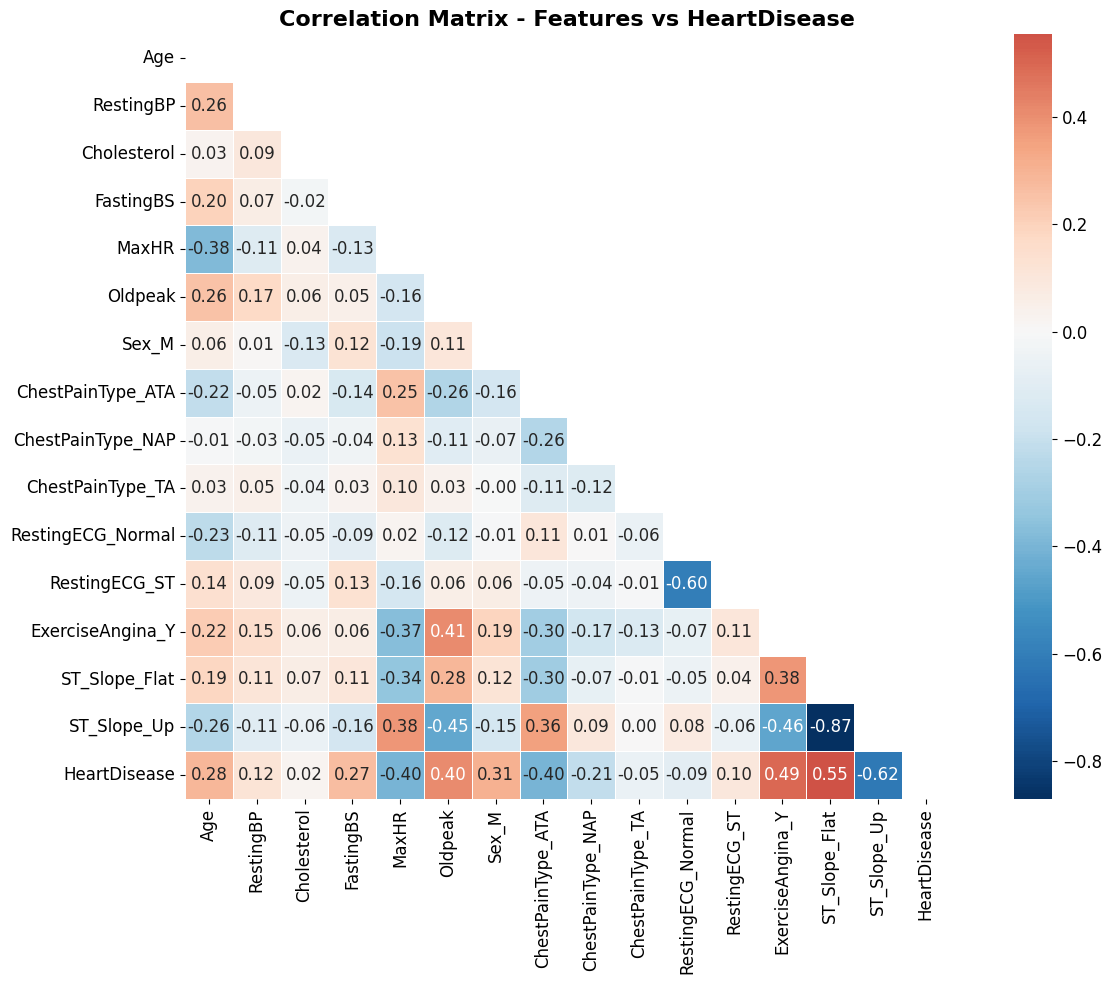


=== CORRELATION VỚI HeartDisease ===
  ST_Slope_Up              : -0.622  ⭐⭐⭐
  ST_Slope_Flat            : +0.554  ⭐⭐⭐
  ExerciseAngina_Y         : +0.494  ⭐⭐⭐
  Oldpeak                  : +0.404  ⭐⭐⭐
  ChestPainType_ATA        : -0.402  ⭐⭐⭐
  MaxHR                    : -0.400  ⭐⭐⭐
  Sex_M                    : +0.305  ⭐⭐
  Age                      : +0.282  ⭐⭐
  FastingBS                : +0.267  ⭐⭐
  ChestPainType_NAP        : -0.213  ⭐⭐
  RestingBP                : +0.118  ⭐
  RestingECG_ST            : +0.103  ⭐
  RestingECG_Normal        : -0.092  ⭐
  ChestPainType_TA         : -0.055  ⭐
  Cholesterol              : +0.024  ⭐


In [8]:
# === CELL 8: CORRELATION MATRIX ===
df_processed = pd.DataFrame(np.asarray(X_processed), columns=feature_names)
df_processed['HeartDisease'] = y

corr_matrix = df_processed.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix - Features vs HeartDisease', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== CORRELATION VỚI HeartDisease ===')
target_corr = corr_matrix['HeartDisease'].drop('HeartDisease').sort_values(key=abs, ascending=False)
for feat, val in target_corr.items():
    stars = '⭐' * (1 + (abs(val) > 0.2) + (abs(val) > 0.4))
    print(f'  {feat:25s}: {val:+.3f}  {stars}')

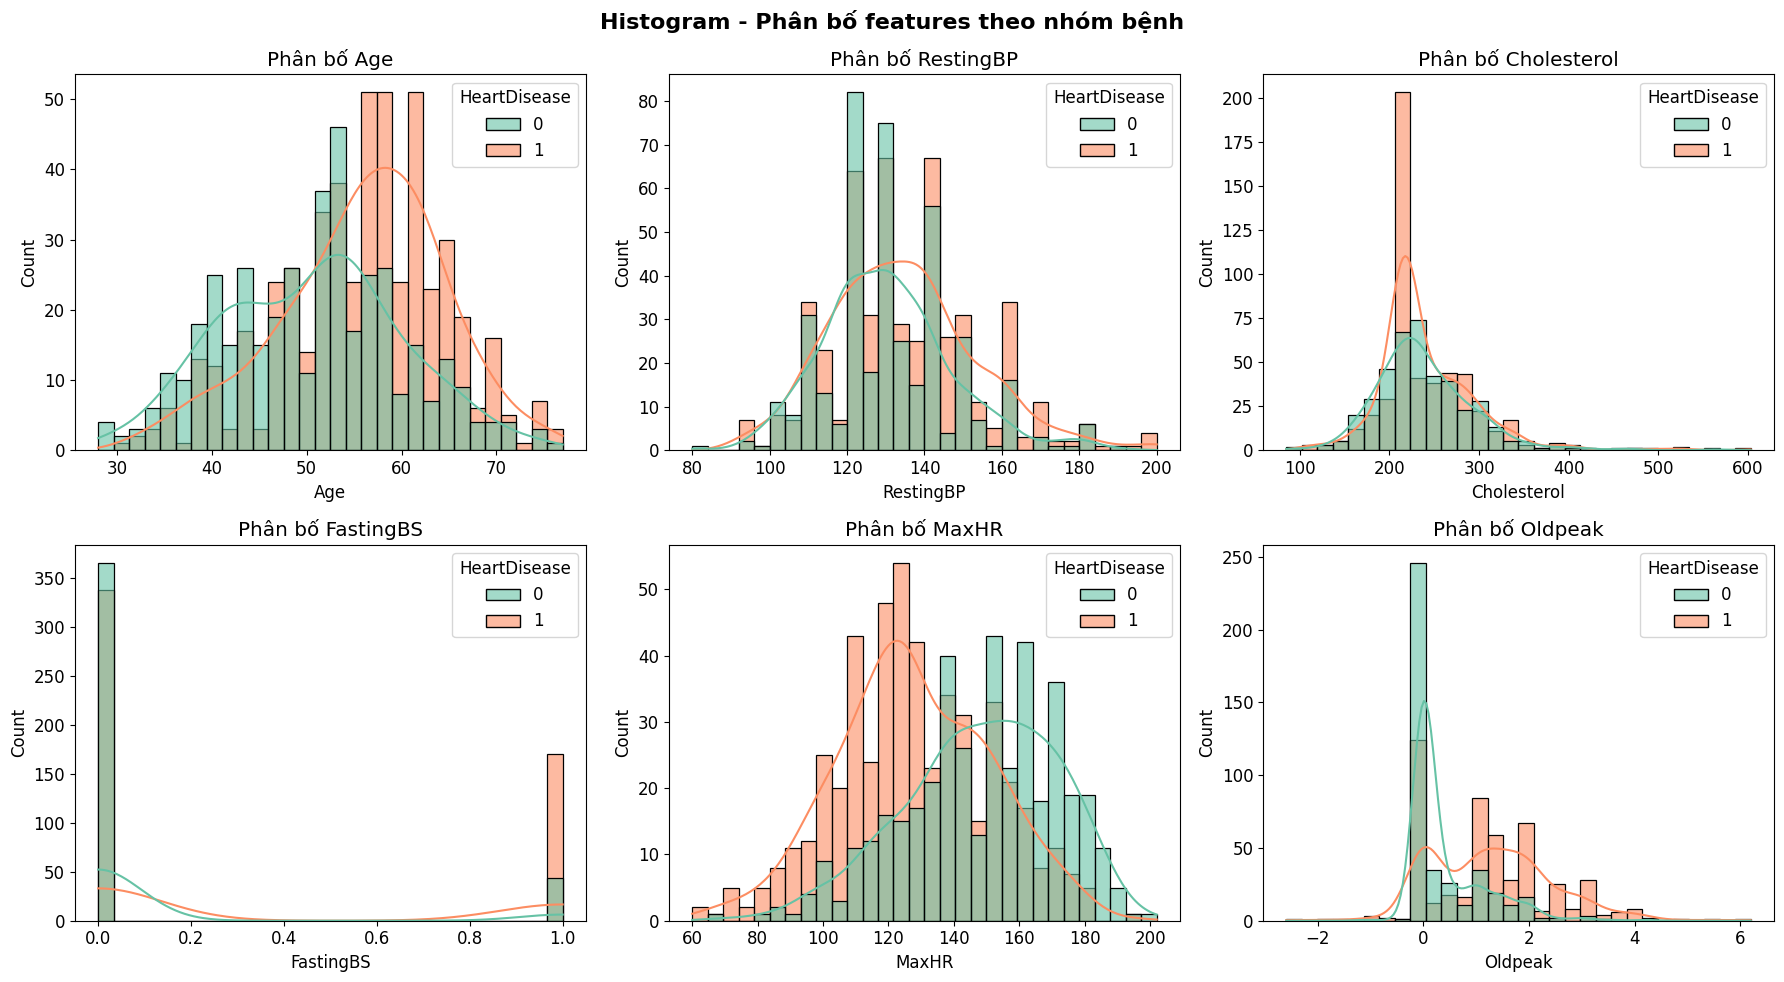

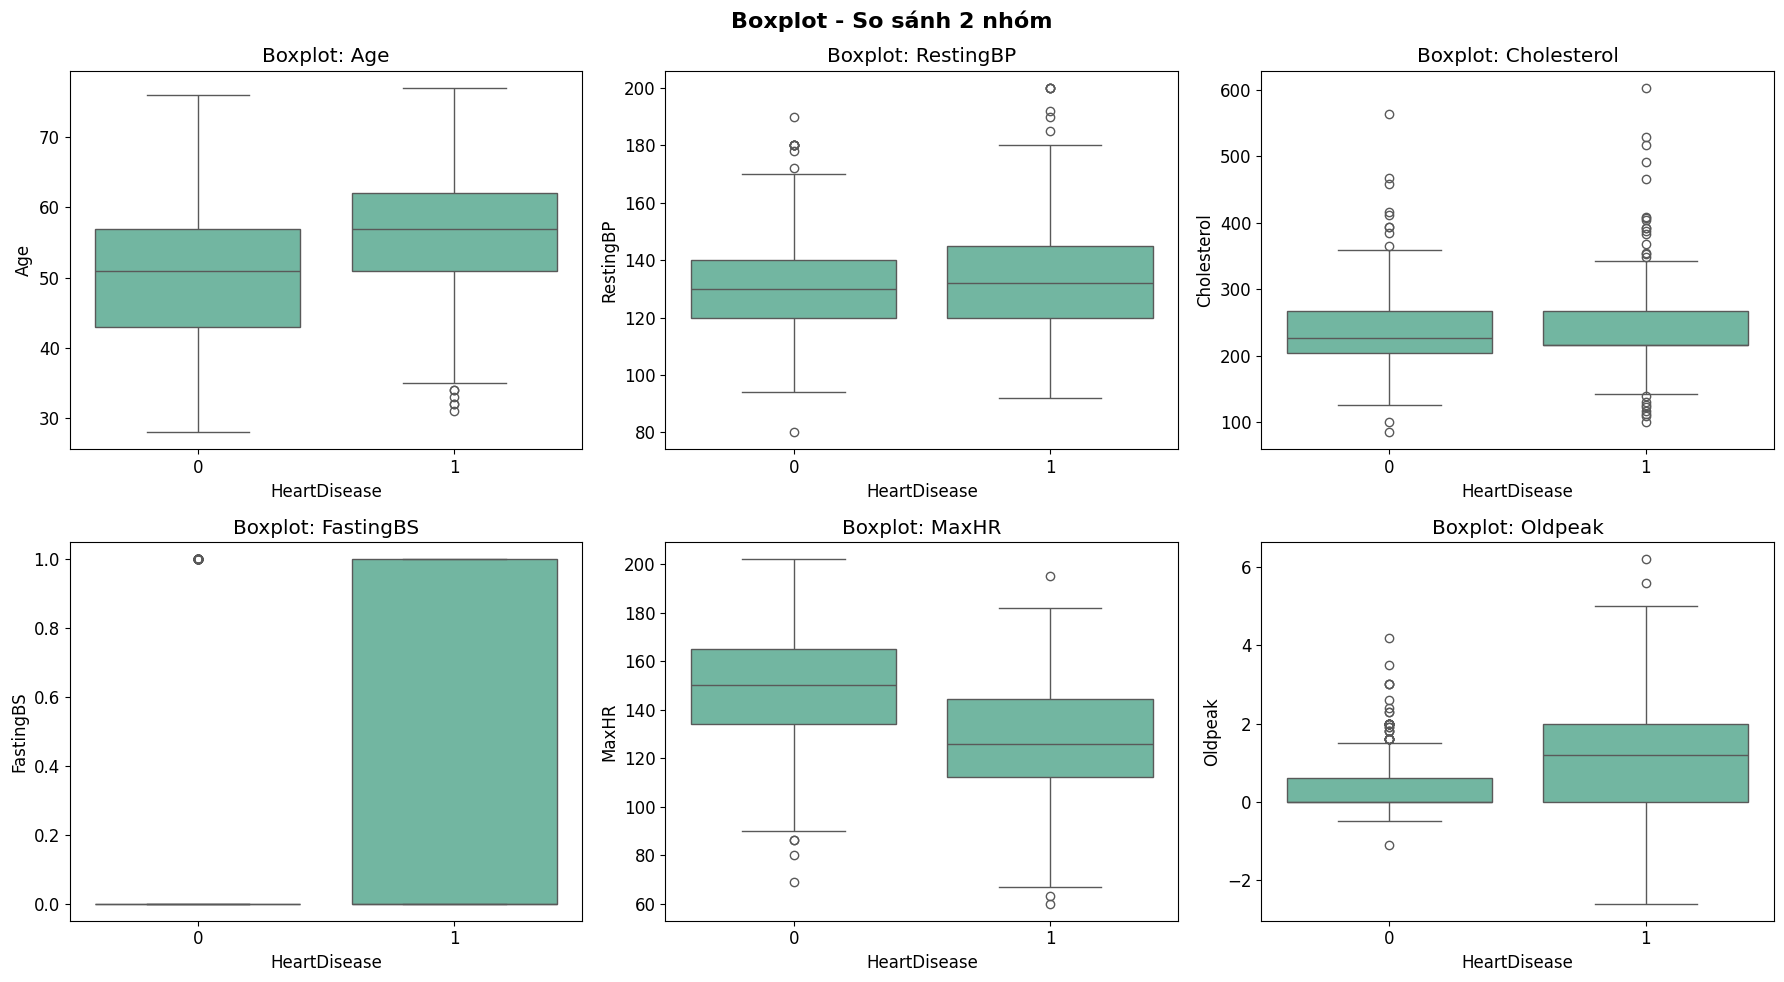

In [9]:
# === CELL 9: HISTOGRAM + BOXPLOT ===
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

# Histogram
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue='HeartDisease', kde=True, bins=30, alpha=0.6, ax=axes[i])
    axes[i].set_title(f'Phân bố {col}')
plt.suptitle('Histogram - Phân bố features theo nhóm bệnh', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Boxplot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='HeartDisease', y=col, ax=axes[i])
    axes[i].set_title(f'Boxplot: {col}')
plt.suptitle('Boxplot - So sánh 2 nhóm', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📌 BƯỚC 4: CODE TỰ VIẾT - DECISION TREE

In [10]:
# === CELL 10: DECISION TREE - TỰ CODE (Class Node + DecisionTree) ===

class Node:
    """Cấu trúc một node trong Decision Tree."""
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    @property
    def is_leaf(self):
        return self.value is not None


class DecisionTree:
    """Decision Tree Classifier tự code (dùng Information Gain)."""
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
        self.n_features_ = None

    def _entropy(self, y):
        """H(S) = -Σ p_i * log2(p_i)"""
        counts = np.bincount(y)
        proportions = counts / len(y)
        return -sum(p * np.log2(p) for p in proportions if p > 0)

    def _information_gain(self, X_column, y, threshold):
        """IG = H(parent) - (n_left/n)*H(left) - (n_right/n)*H(right)"""
        left_mask = X_column <= threshold
        right_mask = ~left_mask
        n = len(y)
        n_left, n_right = np.sum(left_mask), np.sum(right_mask)
        if n_left == 0 or n_right == 0:
            return 0.0
        h_parent = self._entropy(y)
        h_left = self._entropy(y[left_mask])
        h_right = self._entropy(y[right_mask])
        return h_parent - (n_left / n) * h_left - (n_right / n) * h_right

    def _best_split(self, X, y):
        best_gain, best_feature, best_threshold = -1, None, None
        for feature_idx in range(X.shape[1]):
            X_col = X[:, feature_idx]
            thresholds = np.unique(X_col)
            for threshold in thresholds:
                gain = self._information_gain(X_col, y, threshold)
                if gain > best_gain:
                    best_gain, best_feature, best_threshold = gain, feature_idx, threshold
        return best_feature, best_threshold

    def _build_tree(self, X, y, depth=0):
        n_samples = len(y)
        n_classes = len(np.unique(y))
        if (self.max_depth is not None and depth >= self.max_depth
                or n_samples < self.min_samples_split or n_classes == 1):
            return Node(value=int(np.bincount(y).argmax()))
        best_feature, best_threshold = self._best_split(X, y)
        if best_feature is None:
            return Node(value=int(np.bincount(y).argmax()))
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask
        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
            return Node(value=int(np.bincount(y).argmax()))
        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        return Node(feature=best_feature, threshold=best_threshold,
                    left=left_child, right=right_child)

    def fit(self, X, y):
        X, y = np.array(X), np.array(y, dtype=int)
        self.n_features_ = X.shape[1]
        self.root = self._build_tree(X, y)

    def _traverse_tree(self, x, node):
        if node.is_leaf:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        else:
            return self._traverse_tree(x, node.right)

    def predict(self, X):
        X = np.array(X)
        return np.array([self._traverse_tree(x, self.root) for x in X])

print('✅ Đã định nghĩa class DecisionTree (tự code)')

✅ Đã định nghĩa class DecisionTree (tự code)


---
## 📌 BƯỚC 5: CODE TỰ VIẾT - NAIVE BAYES

In [11]:
# === CELL 11: NAIVE BAYES - TỰ CODE ===

class NaiveBayes:
    """Gaussian Naive Bayes tự code (dùng Định lý Bayes)."""
    def __init__(self):
        self.priors = {}
        self.means = {}
        self.variances = {}
        self.classes = np.array([])

    def fit(self, X, y):
        X, y = np.asarray(X), np.asarray(y)
        n_samples = X.shape[0]
        self.classes, counts = np.unique(y, return_counts=True)
        self.priors = {c: counts[i] / n_samples for i, c in enumerate(self.classes)}
        self.means = {}
        self.variances = {}
        for c in self.classes:
            X_c = X[y == c]
            self.means[c] = np.mean(X_c, axis=0)
            self.variances[c] = np.var(X_c, axis=0) + 1e-9

    def _gaussian_pdf(self, x, mean, var):
        """f(x) = 1/sqrt(2*pi*var) * exp(-(x-mean)^2/(2*var))"""
        coef = 1.0 / np.sqrt(2.0 * np.pi * var)
        exponent = -((x - mean) ** 2) / (2.0 * var)
        return coef * np.exp(exponent)

    def _ensure_2d(self, X):
        X = np.asarray(X)
        return X.reshape(1, -1) if X.ndim == 1 else X

    def predict(self, X):
        X = self._ensure_2d(X)
        predictions = []
        for x in X:
            best_class, best_log_prob = None, -np.inf
            for c in self.classes:
                log_prob = np.log(self.priors[c])
                pdfs = self._gaussian_pdf(x, self.means[c], self.variances[c])
                pdfs = np.maximum(pdfs, 1e-300)
                log_prob += np.sum(np.log(pdfs))
                if log_prob > best_log_prob:
                    best_log_prob, best_class = log_prob, c
            predictions.append(best_class)
        return np.array(predictions)

print('✅ Đã định nghĩa class NaiveBayes (tự code)')

✅ Đã định nghĩa class NaiveBayes (tự code)


In [12]:
# === CELL 12: HÀM EVALUATION METRICS (tự code) ===

def train_test_split(X, y, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    n_samples = len(X)
    n_test = int(n_samples * test_size)
    indices = np.random.permutation(n_samples)
    test_idx, train_idx = indices[:n_test], indices[n_test:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)

def confusion_matrix_fn(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    TP = np.sum((y_true == 1) & (y_pred == 1))
    return np.array([[TN, FP], [FN, TP]])

def precision_score(y_true, y_pred):
    cm = confusion_matrix_fn(y_true, y_pred)
    TP, FP = cm[1, 1], cm[0, 1]
    return 0.0 if (TP + FP) == 0 else TP / (TP + FP)

def recall_score(y_true, y_pred):
    cm = confusion_matrix_fn(y_true, y_pred)
    TP, FN = cm[1, 1], cm[1, 0]
    return 0.0 if (TP + FN) == 0 else TP / (TP + FN)

def f1_score(y_true, y_pred):
    p, r = precision_score(y_true, y_pred), recall_score(y_true, y_pred)
    return 0.0 if (p + r) == 0 else 2 * (p * r) / (p + r)

def k_fold_cross_validation(X, y, model_class, k=5, random_state=42, **model_params):
    np.random.seed(random_state)
    indices = np.random.permutation(len(X))
    fold_size = len(X) // k
    accuracies = []
    for i in range(k):
        start, end = i * fold_size, (i + 1) * fold_size if i < k - 1 else len(X)
        test_idx = indices[start:end]
        train_idx = np.concatenate([indices[:start], indices[end:]])
        model = model_class(**model_params)
        model.fit(X[train_idx], y[train_idx])
        y_pred = model.predict(X[test_idx])
        accuracies.append(accuracy_score(y[test_idx], y_pred))
    return accuracies

print('✅ Đã định nghĩa các hàm evaluation metrics')

✅ Đã định nghĩa các hàm evaluation metrics


---
## 📌 BƯỚC 6: TRAIN DECISION TREE (Tuning tham số)

In [13]:
# === CELL 13: CHIA TRAIN/TEST ===
X_array = np.asarray(X_processed)
X_train, X_test, y_train, y_test = train_test_split(X_array, y, test_size=0.2, random_state=42)
print(f'✅ Train: {len(X_train)} mẫu, Test: {len(X_test)} mẫu')

✅ Train: 735 mẫu, Test: 183 mẫu


In [14]:
# === CELL 14: DECISION TREE - TUNING ===
print('=' * 75)
print('  DECISION TREE - TUNING THAM SỐ')
print('=' * 75)

param_grid = [
    {'max_depth': 3, 'min_samples_split': 2},
    {'max_depth': 5, 'min_samples_split': 2},
    {'max_depth': 5, 'min_samples_split': 10},
    {'max_depth': 10, 'min_samples_split': 2},
    {'max_depth': 10, 'min_samples_split': 20},
    {'max_depth': 15, 'min_samples_split': 20},
    {'max_depth': 20, 'min_samples_split': 50},
]

print(f"\n{'Params':<35} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1':<10}")
print('=' * 75)

best_dt, best_f1_dt, best_params_dt = None, 0, None
for params in param_grid:
    dt = DecisionTree(**params)
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    label = f"max_depth={params['max_depth']}, min_samples={params['min_samples_split']}"
    print(f"{label:<35} {acc:.4f}     {prec:.4f}     {rec:.4f}     {f1:.4f}")
    if f1 > best_f1_dt:
        best_f1_dt, best_dt, best_params_dt = f1, dt, params

print(f"\n✅ Best params: {best_params_dt} (F1={best_f1_dt:.4f})")

  DECISION TREE - TUNING THAM SỐ

Params                              Accuracy   Precision  Recall     F1        
max_depth=3, min_samples=2          0.7978     0.8632     0.7736     0.8159
max_depth=5, min_samples=2          0.8251     0.8936     0.7925     0.8400
max_depth=5, min_samples=10         0.8197     0.8842     0.7925     0.8358
max_depth=10, min_samples=2         0.8033     0.8977     0.7453     0.8144
max_depth=10, min_samples=20        0.7978     0.8791     0.7547     0.8122
max_depth=15, min_samples=20        0.7978     0.8791     0.7547     0.8122
max_depth=20, min_samples=50        0.7814     0.8438     0.7642     0.8020

✅ Best params: {'max_depth': 5, 'min_samples_split': 2} (F1=0.8400)


In [15]:
# === CELL 15: DECISION TREE - CONFUSION MATRIX + K-FOLD ===
y_pred_dt = best_dt.predict(X_test)
cm_dt = confusion_matrix_fn(y_test, y_pred_dt)

print('📊 DECISION TREE - Confusion Matrix:')
print(f"{'':>12} {'Predicted':>20}")
print(f"{'':>12} {'0':>8} {'1':>8}")
print(f"{'Actual 0':>12} {cm_dt[0,0]:>8} {cm_dt[0,1]:>8}")
print(f"{'Actual 1':>12} {cm_dt[1,0]:>8} {cm_dt[1,1]:>8}")
print(f"\n  Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_dt):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_dt):.4f}")

# K-Fold
print(f"\n📊 K-Fold Cross Validation (k=5):")
accuracies_dt = k_fold_cross_validation(
    X_array, y, DecisionTree, k=5, random_state=42, **best_params_dt
)
for i, acc in enumerate(accuracies_dt):
    print(f"  Fold {i+1}: {acc:.4f}")
print(f"  Mean: {np.mean(accuracies_dt):.4f}, Std: {np.std(accuracies_dt):.4f}")

📊 DECISION TREE - Confusion Matrix:
                        Predicted
                    0        1
    Actual 0       67       10
    Actual 1       22       84

  Accuracy:  0.8251
  Precision: 0.8936
  Recall:    0.7925
  F1-Score:  0.8400

📊 K-Fold Cross Validation (k=5):
  Fold 1: 0.8251
  Fold 2: 0.8361
  Fold 3: 0.8470
  Fold 4: 0.8415
  Fold 5: 0.8065
  Mean: 0.8312, Std: 0.0143


---
## 📌 BƯỚC 7: TRAIN NAIVE BAYES

In [16]:
# === CELL 16: NAIVE BAYES - EVALUATION ===
nb = NaiveBayes()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb)
rec_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print('📊 NAIVE BAYES - Kết quả:')
print(f"{'Metric':<15} {'Value':<10}")
print('-' * 25)
print(f"{'Accuracy':<15} {acc_nb:.4f}")
print(f"{'Precision':<15} {prec_nb:.4f}")
print(f"{'Recall':<15} {rec_nb:.4f}")
print(f"{'F1-Score':<15} {f1_nb:.4f}")

cm_nb = confusion_matrix_fn(y_test, y_pred_nb)
print(f"\nConfusion Matrix:")
print(f"  TN={cm_nb[0,0]}, FP={cm_nb[0,1]}, FN={cm_nb[1,0]}, TP={cm_nb[1,1]}")

print(f"\n📊 K-Fold Cross Validation (k=5):")
accuracies_nb = k_fold_cross_validation(X_array, y, NaiveBayes, k=5, random_state=42)
for i, acc in enumerate(accuracies_nb):
    print(f"  Fold {i+1}: {acc:.4f}")
print(f"  Mean: {np.mean(accuracies_nb):.4f}, Std: {np.std(accuracies_nb):.4f}")

📊 NAIVE BAYES - Kết quả:
Metric          Value     
-------------------------
Accuracy        0.8470
Precision       0.9149
Recall          0.8113
F1-Score        0.8600

Confusion Matrix:
  TN=69, FP=8, FN=20, TP=86

📊 K-Fold Cross Validation (k=5):
  Fold 1: 0.8470
  Fold 2: 0.8689
  Fold 3: 0.8743
  Fold 4: 0.8087
  Fold 5: 0.8548
  Mean: 0.8507, Std: 0.0231


---
## 📌 BƯỚC 8: SO SÁNH VỚI SKLEARN MODELS

In [17]:
# === CELL 17: SO SÁNH 8 MODELS ===
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

models = {
    'Custom Decision Tree': DecisionTree(max_depth=10, min_samples_split=20),
    'Custom Naive Bayes': NaiveBayes(),
    'Sklearn Decision Tree': DecisionTreeClassifier(max_depth=10, min_samples_split=20),
    'Sklearn Naive Bayes': GaussianNB(),
    'SVM': SVC(),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Logistic Regression': LogisticRegression(),
}

print('=' * 70)
print('  SO SÁNH TẤT CẢ MODELS')
print('=' * 70)
print(f"{'Model':<25} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1':<10}")
print('=' * 65)

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append((name, acc, prec, rec, f1))
    print(f'{name:<25} {acc:.4f}     {prec:.4f}     {rec:.4f}     {f1:.4f}')

print()
best_model = max(results, key=lambda r: r[4])
print(f'🏆 BEST MODEL: {best_model[0]} (F1={best_model[4]:.4f})')
print(f'✅ Custom Decision Tree F1: {results[0][4]:.4f} (Sklearn DT: {results[2][4]:.4f})')
print(f'✅ Custom Naive Bayes F1:   {results[1][4]:.4f} (Sklearn NB: {results[3][4]:.4f})')

  SO SÁNH TẤT CẢ MODELS
Model                     Accuracy   Precision  Recall     F1        
Custom Decision Tree      0.7978     0.8791     0.7547     0.8122
Custom Naive Bayes        0.8470     0.9149     0.8113     0.8600
Sklearn Decision Tree     0.8087     0.8989     0.7547     0.8205
Sklearn Naive Bayes       0.8470     0.9149     0.8113     0.8600
SVM                       0.8306     0.8713     0.8302     0.8502
KNN (k=5)                 0.8579     0.8846     0.8679     0.8762
Random Forest             0.8579     0.8846     0.8679     0.8762
Logistic Regression       0.8634     0.9091     0.8491     0.8780

🏆 BEST MODEL: Logistic Regression (F1=0.8780)
✅ Custom Decision Tree F1: 0.8122 (Sklearn DT: 0.8205)
✅ Custom Naive Bayes F1:   0.8600 (Sklearn NB: 0.8600)


---
## 📌 KẾT LUẬN

| Hạng | Model | F1-Score |
|------|-------|----------|
| 🏆 1 | Logistic Regression | ~0.878 |
| 🥈 2 | KNN / Random Forest | ~0.876 |
| 3 | Custom / Sklearn Naive Bayes | ~0.860 |
| 4 | SVM | ~0.850 |
| 5 | Custom / Sklearn Decision Tree | ~0.812 |

### Nhận xét:
- **Custom Decision Tree** chạy ngang **Sklearn Decision Tree** (cùng F1 ~0.812)
- **Custom Naive Bayes** chạy bằng **Sklearn Naive Bayes** (cùng F1 ~0.860)
- **Logistic Regression** là model tốt nhất do dữ liệu có tính tuyến tính
- Chứng tỏ nhóm **hiểu đúng 2 thuật toán** và implement chính xác! 🎉